In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline, PchipInterpolator, UnivariateSpline, Akima1DInterpolator
from matplotlib import pyplot as plt
import pprint as pprint
#import papermill as pm
import scrapbook as sb
from Utils import ReadTheCsv,ReadTheSpill,append_to_dict

class bcolors:
    OK = "\033[92m"  # GREEN
    WARNING = "\033[93m"  # YELLOW
    FAIL = "\033[91m"  # RED
    RESET = "\033[0m"  # RESET COLOR

In [2]:
!pip install scrapbook
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
CutsType = "CutsType2"
run_to_analyze = "ag14370/ag14370.vertex.csv"
bkg_up = 0.0010
bkg_down = 0.0008

In [4]:
runs = {"2025": [run_to_analyze]}

mirG_center = -415 # <----
mirA_center = -671 # <----
zmin = mirA_center - 400 # <----
zgap_min = mirA_center # <----
zmax = mirG_center + 400 # <----
zgap_max = mirG_center # <----

class Zcuts:
    def __init__(self,a,b):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 400
        self.zmax = a + 400
        self.zgap_min = b
        self.zgap_max = a

ZCUTS = Zcuts(-415,-671)

In [5]:
def NupNdown  (data, start, stop, zmin, zmax, zgap_min, zgap_max):
    Ndwn = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zmin) & (data["Z"] < zgap_min)
    Nup  = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zgap_max) & (data["Z"] < zmax)
    return Nup.sum(), Ndwn.sum()

# estimate background

In [6]:
if(True): # < ----
    datacosm = ReadTheCsv("ag13628/ag13628.vertex.csv",  "-1", zmin, zmax, CutsType)
    mask_down = (datacosm["Z"] < zgap_min)
    bkg_down = (mask_down.sum())/6668
    mask_up = (datacosm["Z"] > zgap_max)
    bkg_up = (mask_up.sum())/6668
    print(f"Bkg estimated: up region {bkg_up:.4f} Hz down region {bkg_down:.4f} Hz")

Bkg estimated: up region 0.0010 Hz down region 0.0009 Hz


In [7]:
data = ReadTheCsv(runs["2025"][0],  "-1", zmin, zmax, CutsType)

# Microwave DUMP
mw_cb_start, mw_cb_stop = ReadTheSpill(runs["2025"][0], "\"Microwave Dump\"[0]")

MAMG_start_rampdown, MAMG_stop_rampdown = ReadTheSpill(runs["2025"][0],"\"Ramp down MA and MG\"[0]")

# PreGravityWell
pregravity_start, pregravity_stop = ReadTheSpill(runs["2025"][0], "\"PreGravityWell\"[0]")
pregravity_start1, pregravity_stop1 = ReadTheSpill(runs["2025"][0], "\"PreGravityWell\"[1]")

# Initial OcB Ramp Down
InitOcB_start, InitOcB_stop = ReadTheSpill(runs["2025"][0], "\"Initial OcB Ramp Down\"[0]")

# WaitForQuasitrapped, or boil off
waitForQuasiTrapped_start, waitForQuasiTrapped_stop = ReadTheSpill(runs["2025"][0], "\"WaitForQuasitrapped\"[0]")
waitForQuasiTrapped_start1, waitForQuasiTrapped_stop1 = ReadTheSpill(runs["2025"][0], "\"WaitForQuasitrapped\"[1]")

# Three Segment Ramp Down
start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill(runs["2025"][0],"\"MBMF RampDown\"[0]")

# Oc RampDown
Oc_start_rampdown, Oc_stop_rampdown = ReadTheSpill(runs["2025"][0],"\"Oc RampDown\"[0]")

# Porch
start_RampAllFinalStep, stop_RampAllFinalStep = ReadTheSpill(runs["2025"][0],"\"RampAllFinalStep\"[0]")

print(mw_cb_start)

ag14370/ag14370.vertex.csv
   [2045.457-3581.484]=1536.027s |          "Microwave Dump"[0]         |  171956     8397     8533     5987    85411    65042   199007   118143   331381       267 

ag14370/ag14370.vertex.csv
   [25056.634-25086.936]=  30.302s |          "Ramp down MA and MG"[0]    |    2913      148      150       98     1514     1127     3249     2278     6013         6 

ag14370/ag14370.vertex.csv
   [25087.090-25188.192]= 101.103s |          "PreGravityWell"[0]         |   10770      557      562      419     5823     4298    13211     7853    22129        49 

ag14370/ag14370.vertex.csv
   [25208.404-25809.610]= 601.207s |          "PreGravityWell"[1]         |   62030     3195     3454     2325    33586    25612    77206    50266   133480      1203 

ag14370/ag14370.vertex.csv
window "Initial OcB Ramp Down"[0] NOT FOUND
ag14370/ag14370.vertex.csv
   [25919.430-26169.434]= 250.004s |          "WaitForQuasitrapped"[0]    |   25807     1352     1394      919    13999    1

# Time Summary Plot

[200]
0.035045469406120376
17.97563000000082
bin time 17.97563000000082


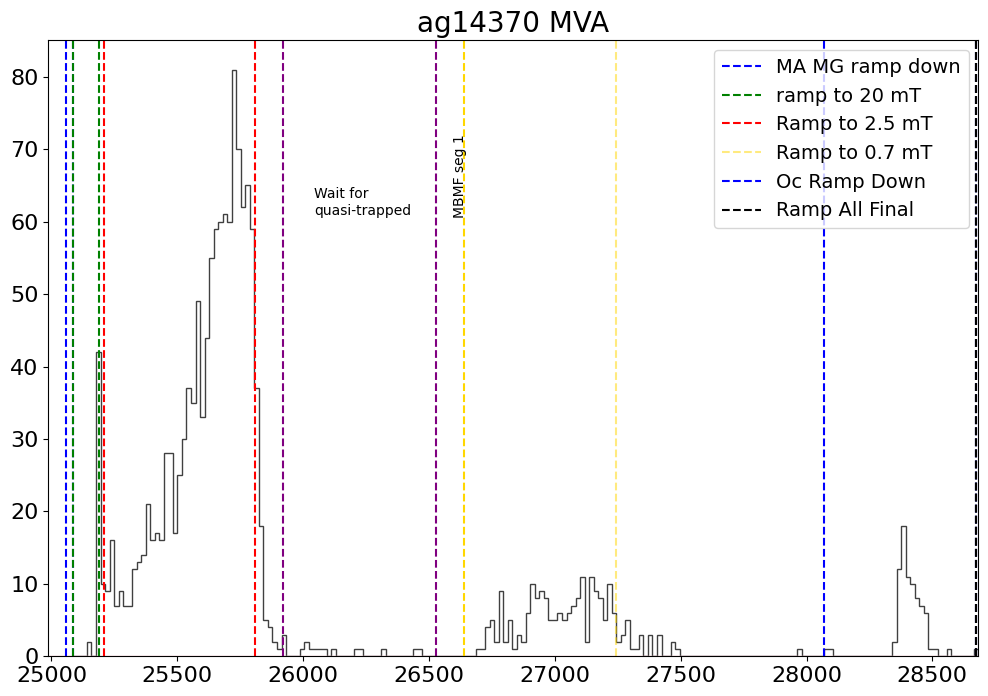

In [8]:
binning = np.array([200])
print(binning)

plt.figure(0, figsize = (12, 8))
plt.title(f"ag{runs['2025'][0].split('/')[0].replace('ag','')} MVA", fontsize = 20)
plt.yticks(fontsize = 16)
plt.xticks(fontsize = 16)
#plt.ylim(0,30)
plt.xlim(pregravity_start[0] - 100, stop_RampAllFinalStep[0] + 10)

TOT_RUN_counts, edges, trash = plt.hist(data["run time"], 
                                        bins = binning[0], 
                                        range =  (pregravity_start[0], stop_RampAllFinalStep[0] + 10) , 
                                        histtype = "step", 
                                        color = "black", 
                                        density = False, 
                                        #label = f"{CutsType}", 
                                        alpha = 0.75)
maxbin = np.max(TOT_RUN_counts)

plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
print((bkg_up + bkg_down) * np.diff(edges)[0])
print(np.diff(edges)[0])

time_bin = np.diff(edges)[0]
print("bin time", time_bin)


plt.axvline(MAMG_start_rampdown[0], linestyle = "--", color = "blue")
plt.axvline(MAMG_stop_rampdown[0],  linestyle = "--", color = "blue", label = "MA MG ramp down")

# Wait-quasi-trapped
plt.axvline(waitForQuasiTrapped_start[0], linestyle = "--", color = "purple")
#plt.axvline(waitForQuasiTrapped_stop[0], linestyle = "--", color = "purple", label = "wait for quasi-trapped")
#plt.axvline(waitForQuasiTrapped_start1[0], linestyle = "--", color = "purple")
plt.axvline(waitForQuasiTrapped_stop1[0], linestyle = "--", color = "purple")
plt.text((waitForQuasiTrapped_start[0] + waitForQuasiTrapped_stop1[0])/2 - 180, maxbin - 20, "Wait for \nquasi-trapped")

# pre-gravity markers
plt.axvline(pregravity_start[0], linestyle = "--", color = "green")
plt.axvline(pregravity_stop[0],  linestyle = "--", color = "green", label = "ramp to 20 mT")
plt.axvline(pregravity_start1[0], linestyle = "--", color = "red")
plt.axvline(pregravity_stop1[0],  linestyle = "--", color = "red", label = "Ramp to 2.5 mT")

# Mirror B-F ramp down
plt.axvline(start_mbmf_rampdown0[0], linestyle = "--", color = "cyan")
plt.axvline(stop_mbmf_rampdown0[0], linestyle = "--", color = "cyan", alpha = 0.5, label = "Ramp to 0.7 mT")
plt.text(start_mbmf_rampdown0[0] - 45, maxbin - 20, "MBMF seg 1",rotation = 90)

# Octupole Ramp Down
plt.axvline(Oc_start_rampdown[0], linestyle = "--", label = "Oc Ramp Down", color = "blue")
plt.axvline(Oc_stop_rampdown[0], linestyle = "--", label = "", color = "blue")

plt.axvline(start_RampAllFinalStep[0], linestyle = "--", label = "Ramp All Final", color = "black")
plt.axvline(stop_RampAllFinalStep[0], linestyle = "--", label = "", color = "black")

#plt.ylim(0,30)

plt.legend( fontsize = 14,
            #loc = "upper right"
          )
plt.savefig(f"figures/Summary_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

## Time distributions during segments

[30]
0.05011843131373929
25.706900000001042
bin time 25.706900000001042


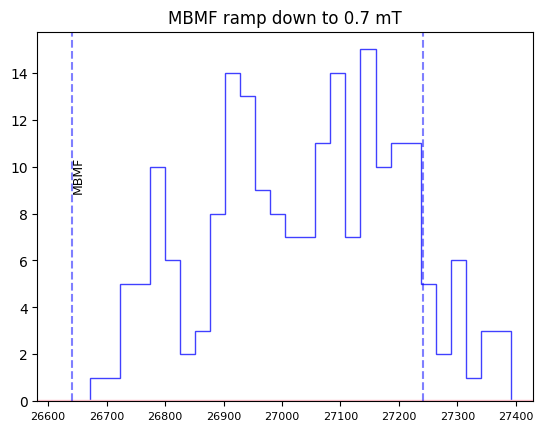

In [9]:
binning = np.array([30])
print(binning)

plt.figure(1)
plt.title("MBMF ramp down to 0.7 mT")

TOT_RUN_counts, edges, trash = plt.hist(data["run time"], 
                                        bins = binning[0], 
                                        range =  (start_mbmf_rampdown0[0] - 20, stop_mbmf_rampdown0[0] + 150), 
                                        histtype = "step", 
                                        color = "blue", 
                                        density = False, 
                                        alpha = 0.75)
maxbin = np.max(TOT_RUN_counts)

plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
print((bkg_up + bkg_down) * np.diff(edges)[0])
print(np.diff(edges)[0])

time_bin = np.diff(edges)[0]
print("bin time", time_bin)

plt.axvline(start_mbmf_rampdown0[0], linestyle = "--", color = "blue", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown0[0], linestyle = "--", color = "blue", alpha = 0.5)
plt.text(start_mbmf_rampdown0[0] - .5, 0.6* maxbin, "MBMF",rotation = 90, fontsize = 9)
plt.xticks(fontsize = 8)
plt.savefig(f"figures/Ramps_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# Mirror B and F three segments + QuasiTrapped

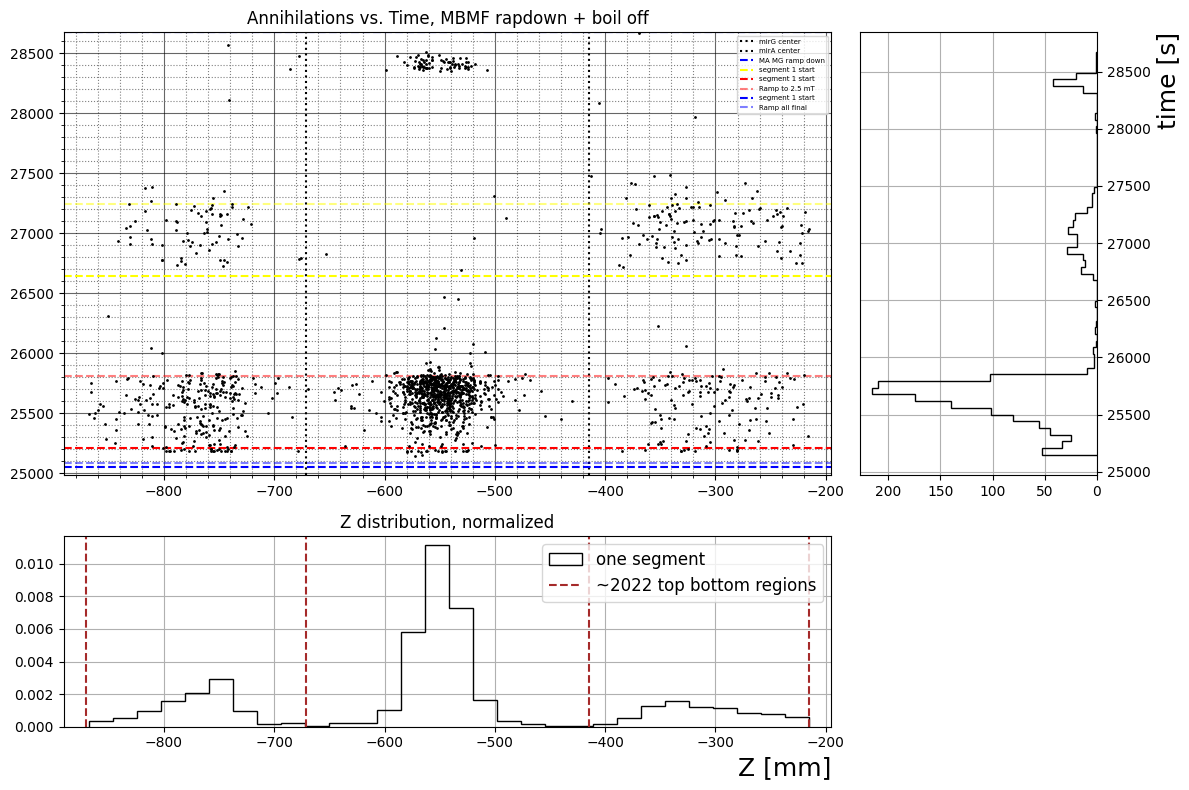

In [19]:
mask   = (data["run time"] > pregravity_start[0] - 100) & (data["run time"] < stop_RampAllFinalStep[0])
fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga


ax1.errorbar(data["Z"][mask], data["run time"][mask] , color = "black", marker = ".", linestyle = "", markersize = 2)
ax1.axvline(mirG_center, linestyle = "dotted", color = "black", label = "mirG center")
ax1.axvline(mirA_center, linestyle = "dotted", color = "black", label = "mirA center")
ax1.axhline(MAMG_start_rampdown[0], linestyle = "--", label = "MA MG ramp down", color = "blue")
ax1.axhline(MAMG_stop_rampdown[0], linestyle = "--", color = "blue", alpha = 0.5)
ax1.axhline(start_mbmf_rampdown0[0], linestyle = "--", label = "ramp to 0.7 mT", color = "cyan")
ax1.axhline(stop_mbmf_rampdown0[0], linestyle = "--", color = "cyan", alpha = 0.5)
ax1.axhline(pregravity_start1[0], linestyle = "--", color = "red")
ax1.axhline(pregravity_stop1[0], linestyle = "--", color = "red", label = "Ramp to 2.5 mT", alpha = 0.5)
ax1.axhline(start_RampAllFinalStep[0], linestyle = "--", label = "segment 1 start", color = "blue")
ax1.axhline(stop_RampAllFinalStep[0], linestyle = "--", color = "blue", label = "Ramp all final", alpha = 0.5)


ax1.set_title("Annihilations vs. Time, MBMF rapdown + boil off")
ax1.set_xlim(zmin-20,zmax+20)
ax1.set_ylim(pregravity_start[0] - 100, stop_RampAllFinalStep[0])
ax1.legend(fontsize = 8, loc = "upper right")
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(data["Z"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"one segment")
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)
ax2.grid()


counts, bins, _ = ax3.hist(data["run time"][mask], bins = 60, histtype = "step",  color = "black", density = False,  orientation='horizontal')
ax1.set_ylim(pregravity_start[0] - 100, stop_RampAllFinalStep[0])
xgrid = np.linspace(bins[4], bins[-1], 100)

#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()
ax3.grid()

plt.tight_layout()
plt.show()
fig.savefig(f"figures/MBMF_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png",bbox_inches = 'tight')

# Z pdf for the three segments

## Z Only segments

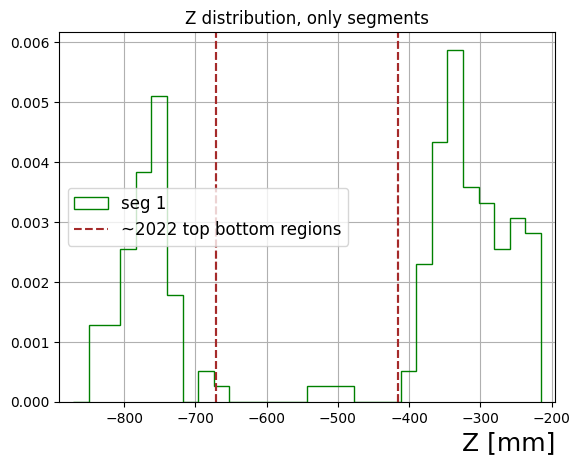

In [11]:
ax = plt.subplot(1,1,1)  # occuopa 3 righe

mask_seg0   = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < stop_mbmf_rampdown0[0])

#print(stop_mbmf_rampdown0[0],start_mbmf_rampdown1[0] )

ax.set_title("Z distribution, only segments")
ax.set_xlabel("Z [mm]", loc = "right", fontsize = 18)

ax.hist(data["Z"][mask_seg0], 
        bins = 30, 
        range = [zmin, zmax],
        histtype = "step", 
        color = "green", 
        density = True,  
        label = f"seg 1")

ax.axvline(zmin + 200,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax.axvline(zmax - 200,linestyle = "--", color = "brown")
ax.axvline(zgap_min,linestyle = "--", color = "brown")
ax.axvline(zgap_max,linestyle = "--", color = "brown")
ax.set_xlim(zmin-20,zmax+20)
ax.legend(fontsize = 12)
ax.grid()
plt.savefig(f"figures/Zpds_three_segments_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png",bbox_inches = 'tight')

## Boiling atoms

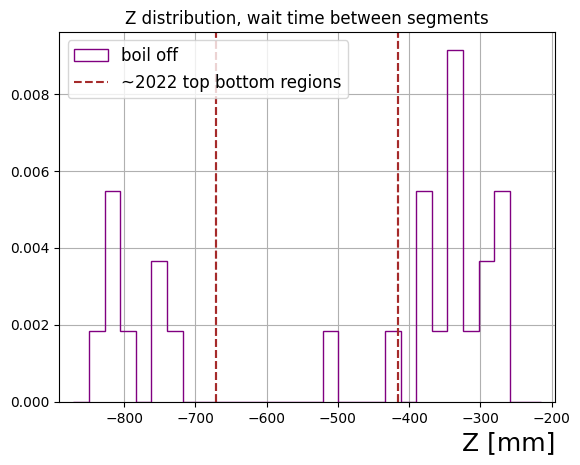

In [12]:
ax = plt.subplot(1,1,1)  # occuopa 3 righe

mask_seg0   = (data["run time"] > stop_mbmf_rampdown0[0]) & (data["run time"] < stop_mbmf_rampdown0[0] + 600)

ax.set_title("Z distribution, wait time between segments")
ax.set_xlabel("Z [mm]", loc = "right", fontsize = 18)


ax.hist(data["Z"][mask_seg0], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "purple", 
        density = True,  
        label = f"boil off")


ax.axvline(zmin + 200,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax.axvline(zmax - 200,linestyle = "--", color = "brown")
ax.axvline(zgap_min,linestyle = "--", color = "brown")
ax.axvline(zgap_max,linestyle = "--", color = "brown")
ax.set_xlim(zmin-20,zmax+20)
ax.legend(fontsize = 12)
ax.grid()
plt.savefig(f"figures/Zpds_boiloff_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png",bbox_inches = 'tight')

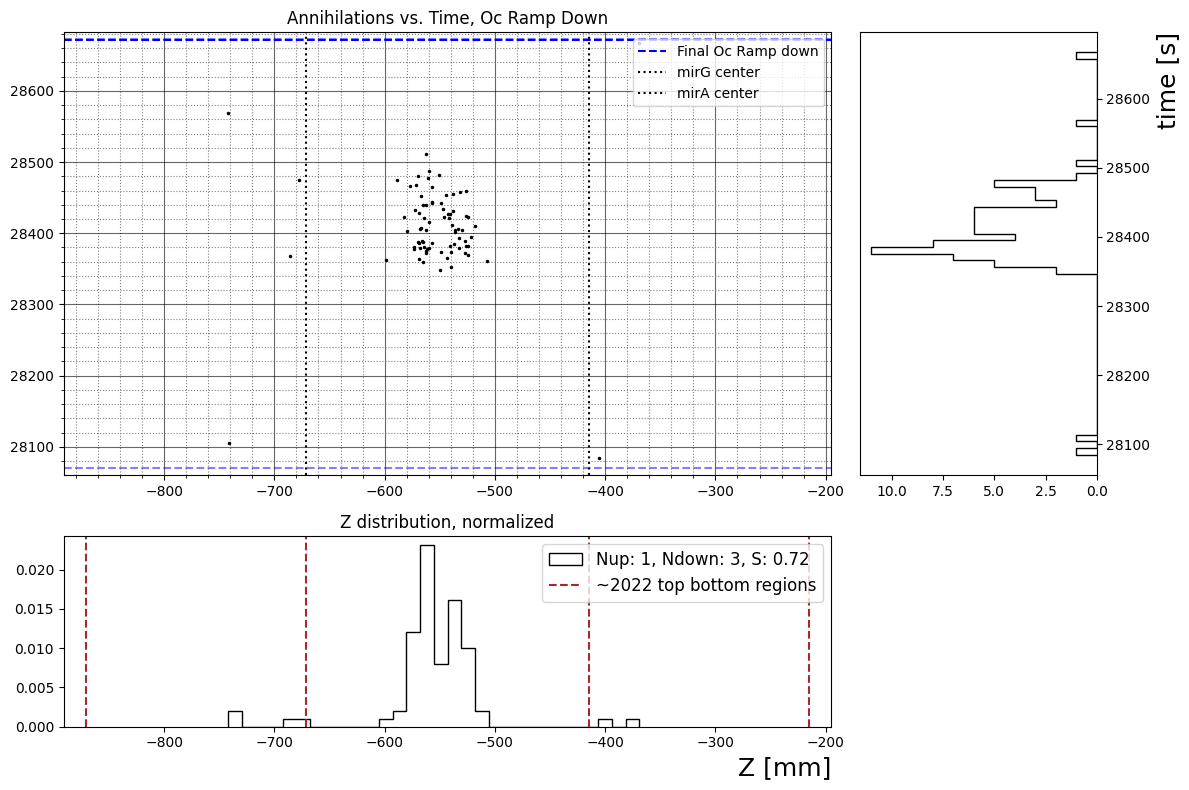

In [13]:
mask = (data["run time"] > Oc_start_rampdown[0]) & (data["run time"] < Oc_stop_rampdown[0])

Nup, Ndown = NupNdown(data, Oc_start_rampdown[0], Oc_stop_rampdown[0], zmin, zmax, zgap_min, zgap_max)
Nup = Nup - bkg_up * (Oc_stop_rampdown[0] - Oc_start_rampdown[0])
Ndown = Ndown - bkg_down * (Oc_stop_rampdown[0] - Oc_start_rampdown[0])

S = Ndown/(Nup + Ndown)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga

ax1.set_title("Annihilations vs. Time, Oc Ramp Down")

ax1.errorbar(data["Z"][mask], data["run time"][mask] , color = "black", marker = ".", markersize = 3, linestyle = "")
ax1.axhline(Oc_start_rampdown[0], linestyle = "--", color = "blue", alpha = 0.5)
ax1.axhline(start_RampAllFinalStep[0], linestyle = "--", label = "Final Oc Ramp down", color = "blue")
ax1.axhline(stop_RampAllFinalStep[0], linestyle = "--", color = "blue", alpha = 0.5)
ax1.axvline(mirG_center, linestyle = "dotted", color = "black", label = "mirG center")
ax1.axvline(mirA_center, linestyle = "dotted", color = "black", label = "mirA center")
ax1.set_ylim(Oc_start_rampdown[0]- 10, stop_RampAllFinalStep[0] + 10)

# ax1.legend(fontsize = 20)
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

ax1.legend(loc = "upper right")
ax1.set_xlim(zmin-20,zmax+20)


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(data["Z"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {int(Nup)}, Ndown: {int(Ndown)}, S: {S:.2}")
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)

counts, bins, _ = ax3.hist(data["run time"][mask], bins = 60, histtype = "step", color = "black", density = False, orientation='horizontal')

#ax3.axhline(timecut, linestyle = "--", color = "black")
#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()

plt.tight_layout()
plt.show()
fig.savefig(f"figures/Oc_RampDown{runs['2025'][0].split('/')[0].replace('ag','')}.png",bbox_inches = 'tight')

# R, phi distributions

In [14]:
def cart2cyl(x, y, z, degrees=False):
    """
    Versione vettoriale (accetta float o array-like) basata su NumPy.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    r = np.hypot(x, y)
    phi = np.arctan2(y, x)                   # (-π, π]
    phi = np.mod(phi, 2 * np.pi)/np.pi       # [0, 2π)

    if degrees:
        phi = np.degrees(phi)

    return phi

In [15]:
data["phi"] = cart2cyl(data["X"], data["Y"], data["Z"])

50 50


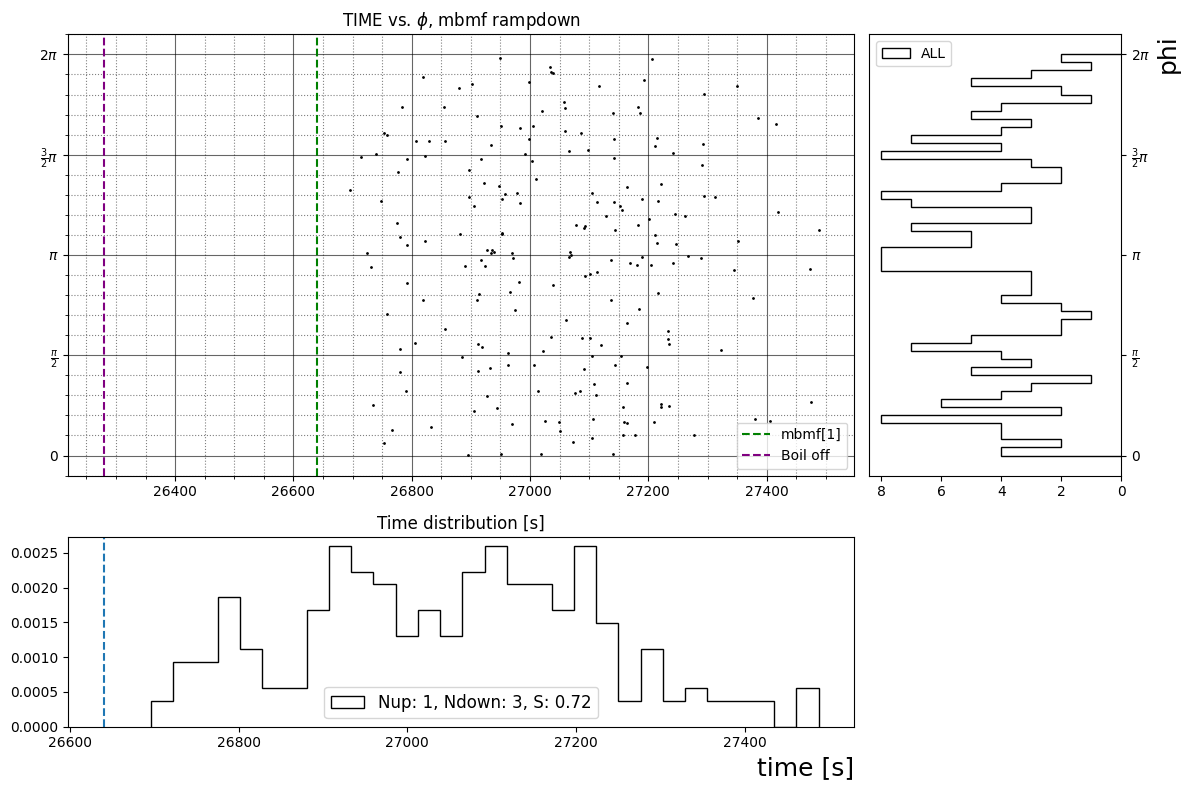

In [16]:
# compute the radius
mask = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < stop_mbmf_rampdown0[0] + 600)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occupa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occupa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occupa 1 riga

ax1.errorbar(data["run time"][mask], data["phi"][mask] , color = "black", marker = ".", linestyle = "", markersize = 2)

ax1.set_title(r"TIME vs. $\phi$, mbmf rampdown")
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigiaax1.set_ylim(0, 2)

ax1.set_yticks([0, 0.5, 1, 1.5, 2])
ax1.set_yticklabels([
    "0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$"
])
ax1.set_ylim(-0.1, 2.1)

#ax1.axvline(start_mbmf_rampdown[0], linestyle = "--", label = "mbmf[0]", color = "orange")
ax1.axvline(start_mbmf_rampdown0[0], linestyle = "--", label = "mbmf[1]", color = "green")

ax1.axvline(waitForQuasiTrapped_start1[0], linestyle = "--", label = "Boil off", color = "Purple")
ax1.legend()


ax2.hist(data["run time"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {int(Nup)}, Ndown: {int(Ndown)}, S: {S:.2}")
ax2.set_title("Time distribution [s]")
ax2.set_xlabel("time [s]", loc = "right", fontsize = 18)
ax2.legend(fontsize = 12)
#ax2.axvline(start_mbmf_rampdown[0], linestyle = "--")
ax2.axvline(start_mbmf_rampdown0[0], linestyle = "--")

counts, bins, _ = ax3.hist(data["phi"][mask], bins = 50, range = (0,2),  histtype = "step", color = "black", density = False, orientation='horizontal', label = "ALL")

print(len(bins[:-1]), len(counts))
ax3.set_ylim(-0.1, 2.1)
ax3.set_ylabel("phi", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")

ax3.set_yticks([0, 0.5, 1, 1.5, 2])
ax3.set_yticklabels([
    "0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$"
])

ax3.invert_xaxis()
ax3.legend()

plt.tight_layout()
plt.show()
fig.savefig(f"figures/TimevsPHI_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png",bbox_inches = 'tight')

# Glue the result in the Notebook and retrieve them later

In [17]:
def ScurveExtractor(label, data, tstart, tstop, zcuts):
    
    Nup, Ndown = NupNdown(data, tstart, tstop, zcuts.zmin, zcuts.zmax, zcuts.zgap_min, zcuts.zgap_max)
    Nup        = Nup - bkg_up * (tstop - tstart)
    Ndown      = Ndown - bkg_down * (tstop - tstart)

    if((Nup + Ndown) > 0):
        S = (Ndown - Nup)/(Nup + Ndown)
    else:
        S = np.nan
    
    result = S
    
    if((Nup + Ndown) > 0):
        dResult = np.sqrt(abs(1 - S**2)/(Nup + Ndown))
    else:
        dResult = np.nan

    sb.glue(label, [result, dResult])

    print(label, f"Nup {Nup:.1f}, Ndown {Ndown:.1f}")
    
    return 0

In [18]:
###--------------------
ScurveExtractor("ramp_single", data, start_mbmf_rampdown0[0], stop_mbmf_rampdown0[0], ZCUTS) # first segment
ScurveExtractor("ramp_single_wait", data, stop_mbmf_rampdown0[0], stop_mbmf_rampdown0[0]+200, ZCUTS) # first segment

ramp_single Nup 110.4, Ndown 63.5


ramp_single_wait Nup 12.8, Ndown 7.8


0